In [39]:
import torch
import numpy as np
from networks.PeakDetectionModel import PeakDetectionModel
import matplotlib.pyplot as plt
import numpy as np

from run import prepare_dataset

In [40]:
# -------------------- PARAMETRI HARD-CODED --------------------
signal_path = "data/signal.raw"
info_path = "data/info.raw"
chunks = 1024
max_peaks = 3
augment = False
batch_size = 32
shuffle = False
train_split = 0.75
val_split = 0.15

# -------------------- CONFIGURAZIONE --------------------
model_path = "networks\\checkpoints\\model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    augment = augment
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    device = device

args = Config()

print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")


Running inference on device: cuda
Loading model from: networks\checkpoints\model.pt


In [41]:
#-------------------- DATASET --------------------
_, _, test_loader = prepare_dataset(args)

[INFO] Dataset loaded with 50000 signals (augment=False)
[INFO] Train set: 37500 | Val set: 7500 | Test set: 5000


In [42]:
# -------------------- MODELLO --------------------
model = PeakDetectionModel(signal_length=chunks)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

PeakDetectionModel(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(15,), stride=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=31872, out_features=2048, bias=True)
    (1): ReLU()
  )
  (fc_positions): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_heights): Linear(in_features=2048, out_features=3, bias=True)
  (fc_width): Linear(in_features=2048, out_features=3, bias=True)
  (sigmoid): Sigmoid()
)

In [43]:
# -------------------- INFERENZA --------------------
all_predictions = []
with torch.no_grad():
    for i, (signal, _, _, _) in enumerate(test_loader):
        signal = signal.to(device)
        pred_pos, pred_height, pred_width = model(signal.unsqueeze(1))

        preds = {
            "positions": pred_pos.cpu().numpy(),
            "heights": pred_height.cpu().numpy(),
            "widths": pred_width.cpu().numpy()
        }
        all_predictions.append(preds)

        if i % 10 == 0:
            print(f"Batch {i}: positions {pred_pos.shape}, heights {pred_height.shape}, widths {pred_width.shape}")


Batch 0: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 10: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 20: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 30: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 40: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 50: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 60: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 70: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 80: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 90: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
B

In [44]:

# Stampa alcune informazioni
print("Predizioni posizioni (shape):", all_predictions[0]["positions"].shape)
print("Predizioni altezze (shape):", all_predictions[0]["heights"].shape)
print("Predizioni larghezze (shape):", all_predictions[0]["widths"].shape)

# Se vuoi vedere i primi 10 valori di ogni predizione
print("\nPrime 10 posizioni predette:", all_predictions[0]["positions"][0][:10])
print("Prime 10 altezze predette:", all_predictions[0]["heights"][0][:10])
print("Prime 10 larghezze predette:", all_predictions[0]["widths"][0][:10])


Predizioni posizioni (shape): (32, 1024)
Predizioni altezze (shape): (32, 3)
Predizioni larghezze (shape): (32, 3)

Prime 10 posizioni predette: [4.5440657e-27 2.2716981e-27 6.4460918e-26 4.4032662e-28 7.2808996e-26
 1.2353978e-27 2.0762149e-27 4.6683377e-28 4.1379198e-29 4.3411891e-28]
Prime 10 altezze predette: [89.87416  0.       0.     ]
Prime 10 larghezze predette: [0. 0. 0.]


In [45]:
# -------------------- PRENDI PRIMO BATCH E INFERENZA --------------------
with torch.no_grad():
    for signals, true_pos, true_height, true_width in test_loader:
        signals = signals.to(device)
        pred_pos, pred_heights, pred_widths = model(signals.unsqueeze(1))
        
        # Stacca i tensori dal grafo prima di passare a numpy
        pred_pos = pred_pos.detach().cpu().numpy()
        pred_heights = pred_heights.detach().cpu().numpy()
        pred_widths = pred_widths.detach().cpu().numpy()
        break  # prendiamo solo il primo batch per visualizzare


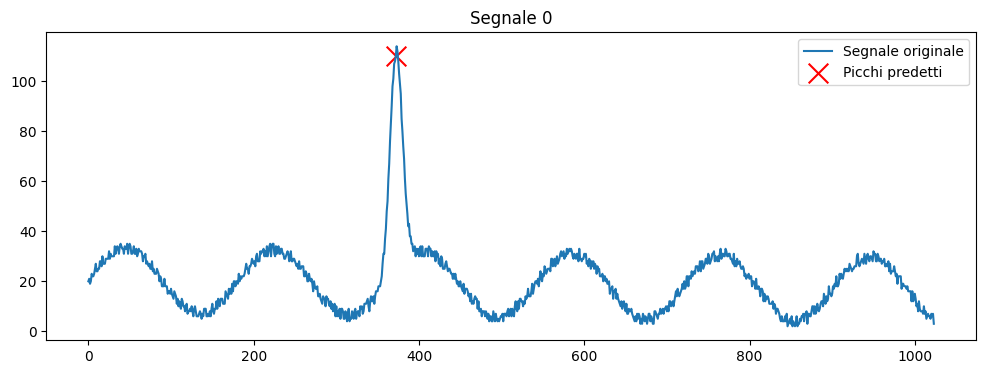

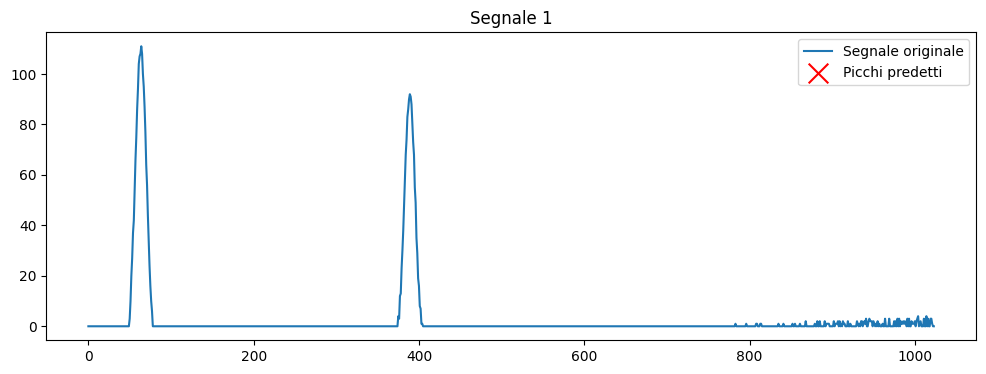

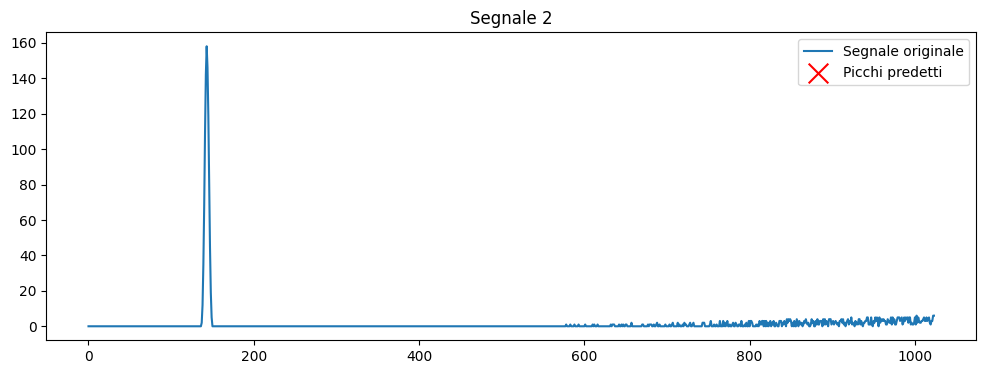

In [49]:
# -------------------- PLOT PRIMI 3 SEGNALI --------------------
for i in range(min(3, signals.shape[0])):  # primi 3 segnali
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]
    heights_pred = pred_heights[i]

    plt.figure(figsize=(12,4))
    plt.plot(signal_example, label="Segnale originale")

    # Threshold per mostrare solo picchi attivi
    threshold = 0.5
    peak_indices = np.where(positions_pred > threshold)[0]

    plt.scatter(peak_indices, signal_example[peak_indices], s=200, color='r', marker='x', label="Picchi predetti")
    plt.title(f"Segnale {i}")
    plt.legend()
    plt.show()

In [ ]:
# -------------------- SALVATAGGIO RISULTATI --------------------
'''np.savez("predictions.npz", **all_predictions[0])
print("\nInference completed.")
print(f"Example predictions saved to 'predictions.npz'")
print(f"Total batches processed: {len(all_predictions)}")'''